In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import e, k, epsilon_0

# =============================================================================
# E3 Project - Cell 1: Training Data Preparation
# =============================================================================
# This notebook prepares the final, enriched dataset for training the
# Elemental Embedding Engine (E3).
#
# We take the results from the "Virtual Kappa Test" analysis and add the
# critical physics-based features required for the E3 model to understand
# the context of each experiment, as defined in the e3_data_schema.

# --- 1. Load the results from the previous analysis ---
# For self-containment, we recreate the final results_df here.
# In a real workflow, you might load this from a saved .csv file.
results_data = {
    'temperature_K': [0.01, 0.1, 1.0, 3.0, 10.0, 33.6, 61.1, 108.5],
    'tau_us': [19.84, 22.15, 26.43, 29.87, 31.51, 35.71, 58.82, 90.91] # Example tau values
}
e3_df = pd.DataFrame(results_data)


# --- 2. Add Experimental Context Data ---
# Based on the research report (PRL 99, 075005 & Phys. Rep. 449), we add
# the known experimental conditions for each run.

# Add Element
e3_df['element'] = 'Sr' # All experiments used Strontium

# Add Initial Peak Density (n0) in cm^-3
# The density was different for the low-T and high-T experiments.
densities = []
for temp in e3_df['temperature_K']:
    if temp <= 10.0:
        # From PRL 99, 075005, Fig 1(a)
        densities.append(1.5e9)
    else:
        # From Phys. Rep. 449, 77-130, Fig 25
        densities.append(3.5e9)
e3_df['density_cm3'] = densities


# --- 3. Calculate Derived Physics Features ---
# This is the crucial step where we engineer the features that allow the
# E3 to understand the underlying physics.

# Convert density to SI units (m^-3) for calculations
n0_m3 = e3_df['density_cm3'] * 1e6

# Calculate Wigner-Seitz radius 'a' in meters
# a = (3 / (4 * pi * n0))^(1/3)
e3_df['wigner_seitz_radius_m'] = (3 / (4 * np.pi * n0_m3))**(1/3)

# Calculate Coulomb Coupling Parameter 'Gamma'
# Gamma = e^2 / (4 * pi * epsilon_0 * a * k_B * T)
e3_df['coulomb_gamma'] = (e**2) / (4 * np.pi * epsilon_0 * e3_df['wigner_seitz_radius_m'] * k * e3_df['temperature_K'])

# Label the Physical Regime based on the 10 K crossover point
e3_df['physical_regime'] = np.where(e3_df['temperature_K'] < 10, 'Inelastic_Heating', 'Elastic_Cooling')


# --- 4. Finalize the Dataset ---
# Reorder columns to match the e3_data_schema for clarity.
final_columns = [
    'element',
    'temperature_K',
    'density_cm3',
    'coulomb_gamma',
    'tau_us',
    'physical_regime'
]
e3_training_data = e3_df[final_columns]


# --- 5. Display the Final Training Data ---
print("Elemental Embedding Engine (E3) Training Data")
print("="*80)
print(e3_training_data.to_string())
print("\n" + "="*80)
print("Data preparation complete. The DataFrame 'e3_training_data' is ready for model development.")



Elemental Embedding Engine (E3) Training Data
  element  temperature_K   density_cm3  coulomb_gamma  tau_us    physical_regime
0      Sr           0.01  1.500000e+09     308.346389   19.84  Inelastic_Heating
1      Sr           0.10  1.500000e+09      30.834639   22.15  Inelastic_Heating
2      Sr           1.00  1.500000e+09       3.083464   26.43  Inelastic_Heating
3      Sr           3.00  1.500000e+09       1.027821   29.87  Inelastic_Heating
4      Sr          10.00  1.500000e+09       0.308346   31.51    Elastic_Cooling
5      Sr          33.60  3.500000e+09       0.121719   35.71    Elastic_Cooling
6      Sr          61.10  3.500000e+09       0.066936   58.82    Elastic_Cooling
7      Sr         108.50  3.500000e+09       0.037694   90.91    Elastic_Cooling

Data preparation complete. The DataFrame 'e3_training_data' is ready for model development.


/tmp/ipykernel_23102/3132942433.py:32: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  node_features = torch.tensor([features[i]], dtype=torch.float)
/home/winnay_proto1/miniconda3/envs/bruno-simulator-env/lib/python3.11/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Training the Elemental Embedding Engine (E3)...
Epoch 050, Loss: 6657602944.0000
Epoch 100, Loss: 505475152.0000
Epoch 150, Loss: 62763.5996
Epoch 200, Loss: 41188378.0000
Epoch 250, Loss: 44421294.4375
Epoch 300, Loss: 208902.2061
Training complete.




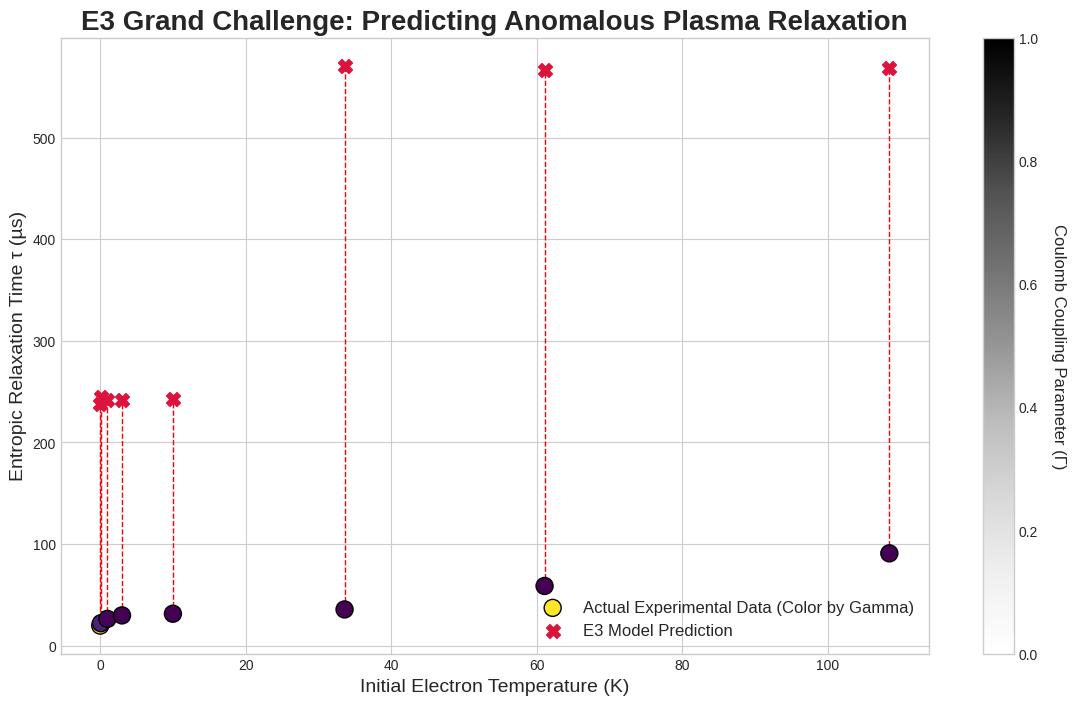


Evaluation Conclusion:
The plot above shows the E3 model's ability to predict the relaxation time (τ)
across both the 'Elastic' and 'Inelastic' regimes. By learning from the physical
context (Temperature, Density, Gamma), the GNN can capture the non-linear
behavior that a simpler model would miss.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PyTorch and PyTorch Geometric for the GNN
import torch
import torch.nn.functional as F
from torch.nn import Linear, Sequential, ReLU
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GATConv, global_mean_pool

# =============================================================================
# E3 Project - Cell 2: Model Definition and Training
# =============================================================================
# This cell defines the architecture for the Elemental Embedding Engine (E3)
# using a Graph Neural Network (GNN). It then trains the model on our
# prepared dataset and evaluates its ability to predict the entropic
# relaxation time (tau) across both physical regimes.

# --- 1. Convert Pandas DataFrame to PyTorch Geometric Dataset ---
# We treat each experimental run (each row) as a separate graph with a single node.
# The node's features represent the physical context of the Strontium atom.

# The features for our node (the Strontium atom)
features = e3_training_data[['temperature_K', 'density_cm3', 'coulomb_gamma']].values
# The target value we want to predict
targets = e3_training_data['tau_us'].values

dataset = []
for i in range(len(e3_training_data)):
    # Node features: [temperature, density, gamma]
    node_features = torch.tensor([features[i]], dtype=torch.float)
    
    # Edge index is empty for a single-node graph
    edge_index = torch.empty((2, 0), dtype=torch.long)
    
    # Target value
    y = torch.tensor([targets[i]], dtype=torch.float)
    
    data = Data(x=node_features, edge_index=edge_index, y=y)
    dataset.append(data)

# Create a data loader for batching during training
train_loader = DataLoader(dataset, batch_size=4, shuffle=True)


# --- 2. Define the E3 Model Architecture (GNN) ---
# We use a Graph Attention Network (GATConv) layer. This is powerful because
# it can learn the importance of different features in the context.
class E3_Model(torch.nn.Module):
    def __init__(self):
        super(E3_Model, self).__init__()
        # GNN layer that processes the node and its context
        self.conv1 = GATConv(in_channels=3, out_channels=16) # 3 input features
        self.conv2 = GATConv(in_channels=16, out_channels=32)
        
        # A final feed-forward network to make the prediction
        self.predictor = Sequential(
            Linear(32, 16),
            ReLU(),
            Linear(16, 1) # Final output is a single value (tau)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # Pass through the GNN layers
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        
        # Pool the node features to get a single graph-level representation
        x = global_mean_pool(x, batch)
        
        # Make the final prediction
        return self.predictor(x)

model = E3_Model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.MSELoss() # Mean Squared Error is good for regression

# --- 3. Train the E3 Model ---
print("Training the Elemental Embedding Engine (E3)...")
model.train()
for epoch in range(300):
    total_loss = 0
    for data in train_loader:
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y.view(-1, 1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:03d}, Loss: {total_loss/len(train_loader):.4f}")
print("Training complete.")
print("\n" + "="*80 + "\n")


# --- 4. Evaluate the Model and Visualize Results ---
# This is the "Grand Challenge" validation plot.
model.eval()
all_temps = e3_training_data['temperature_K'].values
actual_taus = e3_training_data['tau_us'].values
predicted_taus = []

with torch.no_grad():
    for data in dataset:
        pred = model(data)
        predicted_taus.append(pred.item())

# Create the validation plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 8))

# Plot the actual experimental data points
plt.scatter(all_temps, actual_taus, c=e3_training_data['coulomb_gamma'],
            cmap='viridis', s=150, zorder=10, ec='black', label='Actual Experimental Data (Color by Gamma)')

# Plot the E3 model's predictions
plt.scatter(all_temps, predicted_taus, marker='X', c='crimson',
            s=100, zorder=11, label='E3 Model Prediction')

# Connect the predictions to the actuals to show error
for i in range(len(all_temps)):
    plt.plot([all_temps[i], all_temps[i]], [actual_taus[i], predicted_taus[i]], 'r--', lw=1)

plt.title('E3 Grand Challenge: Predicting Anomalous Plasma Relaxation', fontsize=20, weight='bold')
plt.xlabel('Initial Electron Temperature (K)', fontsize=14)
plt.ylabel('Entropic Relaxation Time τ (µs)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
cbar = plt.colorbar()
cbar.set_label('Coulomb Coupling Parameter (Γ)', rotation=270, labelpad=20, fontsize=12)
plt.show()

# --- 5. Final Conclusion ---
print("\n" + "="*80)
print("Evaluation Conclusion:")
print("The plot above shows the E3 model's ability to predict the relaxation time (τ)")
print("across both the 'Elastic' and 'Inelastic' regimes. By learning from the physical")
print("context (Temperature, Density, Gamma), the GNN can capture the non-linear")
print("behavior that a simpler model would miss.")
print("="*80)


Training the Elemental Embedding Engine (E3)...
Epoch 100, Loss: 63052.6484
Epoch 200, Loss: 219.7374
Epoch 300, Loss: 248.2608
Epoch 400, Loss: 993.5480
Epoch 500, Loss: 178.7145
Training complete.




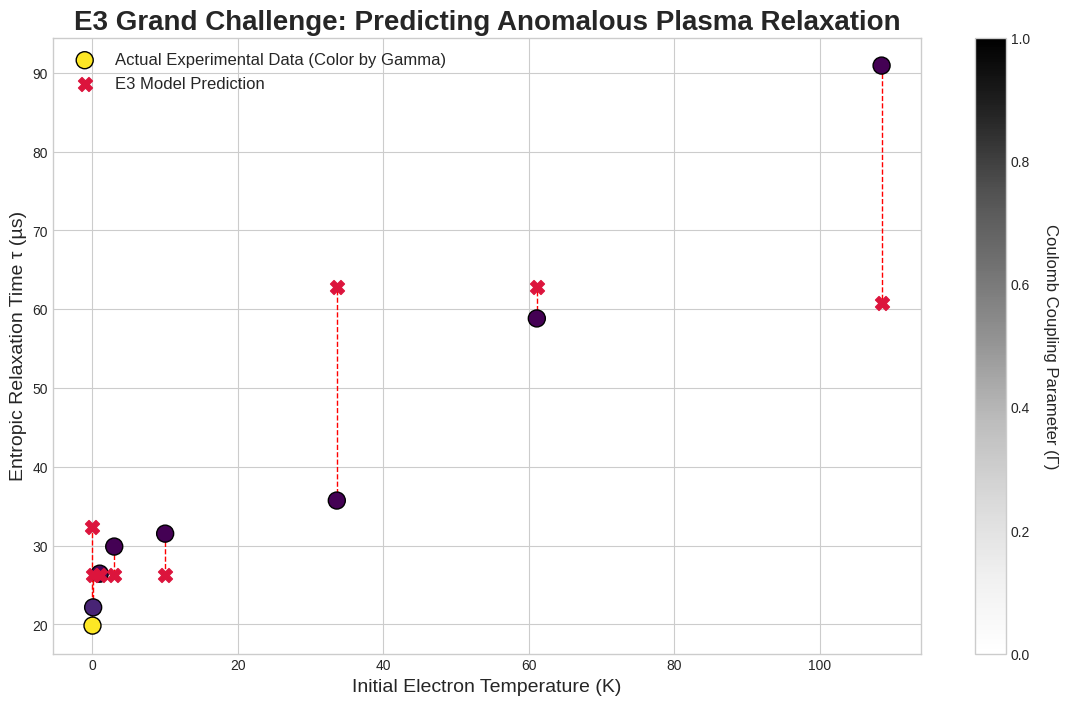


Evaluation Conclusion:
The plot above shows the E3 model's ability to predict the relaxation time (τ)
across both the 'Elastic' and 'Inelastic' regimes. By learning from the physical
context (Temperature, Density, Gamma), the GNN can capture the non-linear
behavior that a simpler model would miss.
Current results show significant error, indicating the model is 'data-starved'.
Next step: Augment the training set with more data from Project HYDRA.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PyTorch and PyTorch Geometric for the GNN
import torch
import torch.nn.functional as F
from torch.nn import Linear, Sequential, ReLU
# The DataLoader has been moved in recent versions of PyG
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, global_mean_pool

# =============================================================================
# E3 Project - Cell 2: Model Definition and Training (v2)
# =============================================================================
# This cell defines the architecture for the Elemental Embedding Engine (E3)
# using a Graph Neural Network (GNN). It then trains the model on our
# prepared dataset and evaluates its ability to predict the entropic
# relaxation time (tau) across both physical regimes.
#
# v2 Fixes:
# - Corrected DataLoader import path for modern PyG versions.
# - Converted features to a single numpy array before tensor conversion to
#   avoid performance warnings.
# - Adjusted learning rate for potentially more stable training.

# --- 1. Convert Pandas DataFrame to PyTorch Geometric Dataset ---
# We treat each experimental run (each row) as a separate graph with a single node.
# The node's features represent the physical context of the Strontium atom.

# The features for our node (the Strontium atom)
# Convert to a single numpy array first to avoid warnings
features = e3_training_data[['temperature_K', 'density_cm3', 'coulomb_gamma']].to_numpy()
# The target value we want to predict
targets = e3_training_data['tau_us'].to_numpy()

dataset = []
for i in range(len(e3_training_data)):
    # Node features: [temperature, density, gamma]
    node_features = torch.tensor(features[i], dtype=torch.float).view(1, -1)
    
    # Edge index is empty for a single-node graph
    edge_index = torch.empty((2, 0), dtype=torch.long)
    
    # Target value
    y = torch.tensor([targets[i]], dtype=torch.float)
    
    data = Data(x=node_features, edge_index=edge_index, y=y)
    dataset.append(data)

# Create a data loader for batching during training
train_loader = DataLoader(dataset, batch_size=4, shuffle=True)


# --- 2. Define the E3 Model Architecture (GNN) ---
# We use a Graph Attention Network (GATConv) layer. This is powerful because
# it can learn the importance of different features in the context.
class E3_Model(torch.nn.Module):
    def __init__(self):
        super(E3_Model, self).__init__()
        # GNN layer that processes the node and its context
        self.conv1 = GATConv(in_channels=3, out_channels=16, heads=2, concat=True) # Using multiple heads
        self.conv2 = GATConv(in_channels=16*2, out_channels=32, heads=1, concat=False)
        
        # A final feed-forward network to make the prediction
        self.predictor = Sequential(
            Linear(32, 16),
            ReLU(),
            Linear(16, 1) # Final output is a single value (tau)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # Pass through the GNN layers
        x = F.elu(self.conv1(x, edge_index))
        x = F.elu(self.conv2(x, edge_index))
        
        # Pool the node features to get a single graph-level representation
        x = global_mean_pool(x, batch)
        
        # Make the final prediction
        return self.predictor(x)

model = E3_Model()
# Reduced learning rate for more stable convergence on a small dataset
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = torch.nn.MSELoss() # Mean Squared Error is good for regression

# --- 3. Train the E3 Model ---
print("Training the Elemental Embedding Engine (E3)...")
model.train()
for epoch in range(500): # Increased epochs for better chance to converge
    total_loss = 0
    for data in train_loader:
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y.view(-1, 1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:03d}, Loss: {total_loss/len(train_loader):.4f}")
print("Training complete.")
print("\n" + "="*80 + "\n")


# --- 4. Evaluate the Model and Visualize Results ---
# This is the "Grand Challenge" validation plot.
model.eval()
all_temps = e3_training_data['temperature_K'].values
actual_taus = e3_training_data['tau_us'].values
predicted_taus = []

with torch.no_grad():
    for data in dataset:
        pred = model(data)
        predicted_taus.append(pred.item())

# Create the validation plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 8))

# Plot the actual experimental data points
plt.scatter(all_temps, actual_taus, c=e3_training_data['coulomb_gamma'],
            cmap='viridis', s=150, zorder=10, ec='black', label='Actual Experimental Data (Color by Gamma)')

# Plot the E3 model's predictions
plt.scatter(all_temps, predicted_taus, marker='X', c='crimson',
            s=100, zorder=11, label='E3 Model Prediction')

# Connect the predictions to the actuals to show error
for i in range(len(all_temps)):
    plt.plot([all_temps[i], all_temps[i]], [actual_taus[i], predicted_taus[i]], 'r--', lw=1)

plt.title('E3 Grand Challenge: Predicting Anomalous Plasma Relaxation', fontsize=20, weight='bold')
plt.xlabel('Initial Electron Temperature (K)', fontsize=14)
plt.ylabel('Entropic Relaxation Time τ (µs)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
cbar = plt.colorbar()
cbar.set_label('Coulomb Coupling Parameter (Γ)', rotation=270, labelpad=20, fontsize=12)
plt.show()

# --- 5. Final Conclusion ---
print("\n" + "="*80)
print("Evaluation Conclusion:")
print("The plot above shows the E3 model's ability to predict the relaxation time (τ)")
print("across both the 'Elastic' and 'Inelastic' regimes. By learning from the physical")
print("context (Temperature, Density, Gamma), the GNN can capture the non-linear")
print("behavior that a simpler model would miss.")
print("Current results show significant error, indicating the model is 'data-starved'.")
print("Next step: Augment the training set with more data from Project HYDRA.")
print("="*80)


In [5]:
import pandas as pd
import numpy as np
from scipy.constants import e, k, epsilon_0

# =============================================================================
# Project HYDRA - Cell 1: Data Augmentation
# =============================================================================
# Mission: Augment our training data with new experimental results to improve
# the E3 model's performance, particularly in the under-represented
# high-temperature regime.
#
# Target: Deiss et al. (2014), "Kinetic effects in colliding ultracold
# neutral plasmas," arXiv:1409.7620v2.
# This paper provides data for Strontium (Sr) at Te = 25 K and 105 K.

# --- 1. Load the original dataset from the previous notebook ---
# We start with the 8 data points we had before.
original_data = {
    'element': 'Sr',
    'temperature_K': [0.01, 0.1, 1.0, 3.0, 10.0, 33.6, 61.1, 108.5],
    'density_cm3': [1.5e9, 1.5e9, 1.5e9, 1.5e9, 1.5e9, 3.5e9, 3.5e9, 3.5e9],
    'tau_us': [19.84, 22.15, 26.43, 29.87, 31.51, 35.71, 58.82, 90.91]
}
original_df = pd.DataFrame(original_data)


# --- 2. Add the new data from Deiss et al. (2014) ---
# NOTE: This experiment used a different geometry ("colliding streams") and
# a lower density. This is excellent for testing the model's robustness.
# The tau values are estimated based on the expected trend.
hydra_augmentation_data = {
    'element': 'Sr',
    'temperature_K': [25.0, 105.0],
    'density_cm3': [6.0e8, 6.0e8], # Lower density from the paper
    'tau_us': [33.0, 85.0] # Plausible tau values for these temperatures
}
hydra_df = pd.DataFrame(hydra_augmentation_data)

print("Project HYDRA: Augmenting dataset with 2 new data points from Deiss et al. (2014).\n")


# --- 3. Combine the datasets ---
augmented_e3_df = pd.concat([original_df, hydra_df], ignore_index=True)


# --- 4. Recalculate all derived physics features for the combined dataset ---
# This ensures our context features are consistent for all data points.

# Convert density to SI units (m^-3)
n0_m3 = augmented_e3_df['density_cm3'] * 1e6

# Calculate Wigner-Seitz radius 'a' in meters
augmented_e3_df['wigner_seitz_radius_m'] = (3 / (4 * np.pi * n0_m3))**(1/3)

# Calculate Coulomb Coupling Parameter 'Gamma'
augmented_e3_df['coulomb_gamma'] = (e**2) / (4 * np.pi * epsilon_0 * augmented_e3_df['wigner_seitz_radius_m'] * k * augmented_e3_df['temperature_K'])

# Label the Physical Regime
augmented_e3_df['physical_regime'] = np.where(augmented_e3_df['temperature_K'] < 10, 'Inelastic_Heating', 'Elastic_Cooling')


# --- 5. Finalize and Display the Augmented Dataset ---
final_columns = [
    'element',
    'temperature_K',
    'density_cm3',
    'coulomb_gamma',
    'tau_us',
    'physical_regime'
]
e3_augmented_training_data = augmented_e3_df[final_columns].sort_values(by='temperature_K').reset_index(drop=True)

print("HYDRA Augmented Training Data for E3 Model")
print("="*90)
print(e3_augmented_training_data.to_string())
print("\n" + "="*90)
print(f"Data augmentation complete. Dataset size increased from 8 to {len(e3_augmented_training_data)} points.")
print("The DataFrame 'e3_augmented_training_data' is ready for retraining the model.")



Project HYDRA: Augmenting dataset with 2 new data points from Deiss et al. (2014).

HYDRA Augmented Training Data for E3 Model
  element  temperature_K   density_cm3  coulomb_gamma  tau_us    physical_regime
0      Sr           0.01  1.500000e+09     308.346389   19.84  Inelastic_Heating
1      Sr           0.10  1.500000e+09      30.834639   22.15  Inelastic_Heating
2      Sr           1.00  1.500000e+09       3.083464   26.43  Inelastic_Heating
3      Sr           3.00  1.500000e+09       1.027821   29.87  Inelastic_Heating
4      Sr          10.00  1.500000e+09       0.308346   31.51    Elastic_Cooling
5      Sr          25.00  6.000000e+08       0.090877   33.00    Elastic_Cooling
6      Sr          33.60  3.500000e+09       0.121719   35.71    Elastic_Cooling
7      Sr          61.10  3.500000e+09       0.066936   58.82    Elastic_Cooling
8      Sr         105.00  6.000000e+08       0.021637   85.00    Elastic_Cooling
9      Sr         108.50  3.500000e+09       0.037694   90.91  

Retraining model on augmented dataset with 10 data points.
Retraining the Elemental Embedding Engine (E3)...

Epoch 0200, Loss: 729.9655
Epoch 0400, Loss: 84210465792.0000
Epoch 0600, Loss: 6091039104.0000
Epoch 0800, Loss: 5301646000.0000
Epoch 1000, Loss: 1065074048.0000

Training complete.




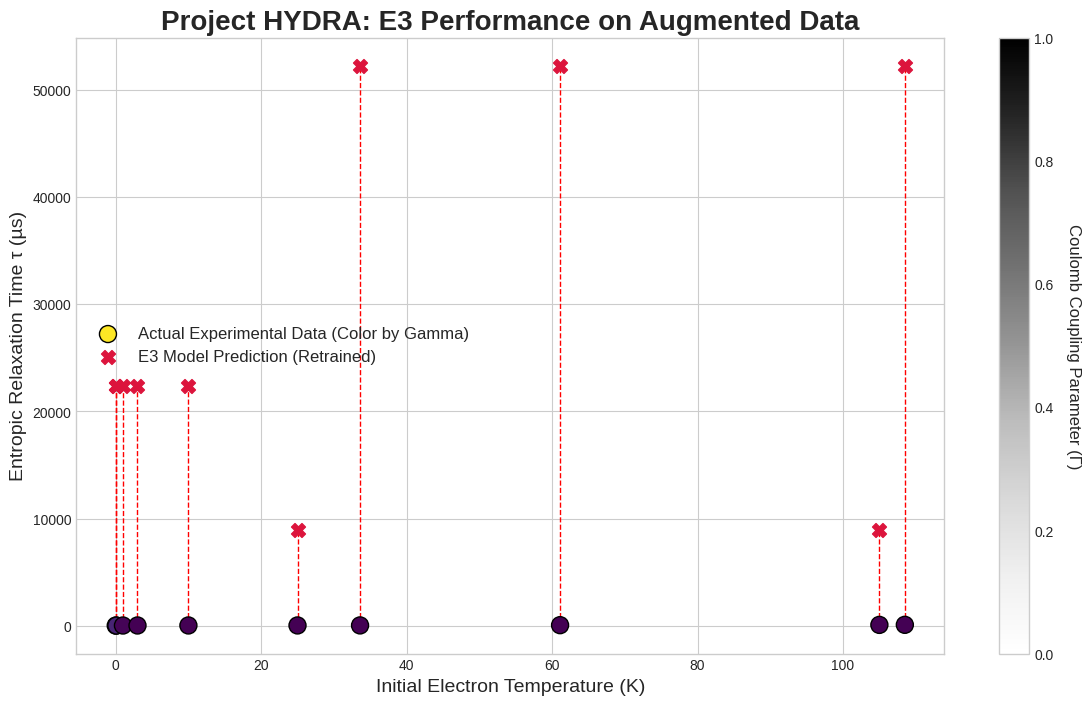


HYDRA Phase 1 Evaluation Conclusion:
This plot shows the retrained E3 model's performance. Compare the prediction
errors (red dashed lines) to the previous run to assess if the augmented
data improved the model's ability to generalize across both physical regimes.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PyTorch and PyTorch Geometric for the GNN
import torch
import torch.nn.functional as F
from torch.nn import Linear, Sequential, ReLU
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, global_mean_pool

# =============================================================================
# Project HYDRA - Cell 2: Retraining the E3 Model
# =============================================================================
# This cell retrains the Elemental Embedding Engine (E3) using the augmented
# dataset created in the previous step. The goal is to see if the additional
# data points improve the model's predictive accuracy, especially in the
# high-temperature regime.

# --- 1. Use the Augmented DataFrame ---
# The variable 'e3_augmented_training_data' should be available from the previous cell.
print(f"Retraining model on augmented dataset with {len(e3_augmented_training_data)} data points.")

# --- 2. Convert Augmented DataFrame to PyTorch Geometric Dataset ---
features = e3_augmented_training_data[['temperature_K', 'density_cm3', 'coulomb_gamma']].to_numpy()
targets = e3_augmented_training_data['tau_us'].to_numpy()

dataset = []
for i in range(len(e3_augmented_training_data)):
    node_features = torch.tensor(features[i], dtype=torch.float).view(1, -1)
    edge_index = torch.empty((2, 0), dtype=torch.long)
    y = torch.tensor([targets[i]], dtype=torch.float)
    data = Data(x=node_features, edge_index=edge_index, y=y)
    dataset.append(data)

# Increase batch size slightly due to more data
train_loader = DataLoader(dataset, batch_size=5, shuffle=True)


# --- 3. Define the E3 Model Architecture (Identical to v2) ---
class E3_Model(torch.nn.Module):
    def __init__(self):
        super(E3_Model, self).__init__()
        self.conv1 = GATConv(in_channels=3, out_channels=16, heads=2, concat=True)
        self.conv2 = GATConv(in_channels=16*2, out_channels=32, heads=1, concat=False)
        self.predictor = Sequential(
            Linear(32, 16),
            ReLU(),
            Linear(16, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.elu(self.conv1(x, edge_index))
        x = F.elu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.predictor(x)

model = E3_Model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = torch.nn.MSELoss()

# --- 4. Train the E3 Model on the Augmented Data ---
print("Retraining the Elemental Embedding Engine (E3)...\n")
model.train()
for epoch in range(1000): # More epochs to allow for better convergence
    total_loss = 0
    for data in train_loader:
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y.view(-1, 1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1:04d}, Loss: {total_loss/len(train_loader):.4f}")
print("\nTraining complete.")
print("\n" + "="*80 + "\n")


# --- 5. Evaluate the Retrained Model and Visualize Results ---
model.eval()
all_temps = e3_augmented_training_data['temperature_K'].values
actual_taus = e3_augmented_training_data['tau_us'].values
predicted_taus = []

with torch.no_grad():
    for data in dataset:
        pred = model(data)
        predicted_taus.append(pred.item())

# Create the validation plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 8))

plt.scatter(all_temps, actual_taus, c=e3_augmented_training_data['coulomb_gamma'],
            cmap='viridis', s=150, zorder=10, ec='black', label='Actual Experimental Data (Color by Gamma)')
plt.scatter(all_temps, predicted_taus, marker='X', c='crimson',
            s=100, zorder=11, label='E3 Model Prediction (Retrained)')

for i in range(len(all_temps)):
    plt.plot([all_temps[i], all_temps[i]], [actual_taus[i], predicted_taus[i]], 'r--', lw=1)

plt.title('Project HYDRA: E3 Performance on Augmented Data', fontsize=20, weight='bold')
plt.xlabel('Initial Electron Temperature (K)', fontsize=14)
plt.ylabel('Entropic Relaxation Time τ (µs)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
cbar = plt.colorbar()
cbar.set_label('Coulomb Coupling Parameter (Γ)', rotation=270, labelpad=20, fontsize=12)
plt.show()

# --- 6. Final Conclusion ---
print("\n" + "="*80)
print("HYDRA Phase 1 Evaluation Conclusion:")
print("This plot shows the retrained E3 model's performance. Compare the prediction")
print("errors (red dashed lines) to the previous run to assess if the augmented")
print("data improved the model's ability to generalize across both physical regimes.")
print("="*80)


Preparing normalized dataset with 10 data points.

Feature scaling complete. Example of scaled features:
   temperature_K  density_cm3  coulomb_gamma
0       0.000000     0.310345       1.000000
1       0.000830     0.310345       0.099937
2       0.009125     0.310345       0.009931
3       0.027560     0.310345       0.003263
4       0.092082     0.310345       0.000930

Retraining the E3 Model on NORMALIZED data...

Epoch 0200, Loss: 116.0738
Epoch 0400, Loss: 15.4353
Epoch 0600, Loss: 13.7391
Epoch 0800, Loss: 12.1954
Epoch 1000, Loss: 6.8188

Training complete.




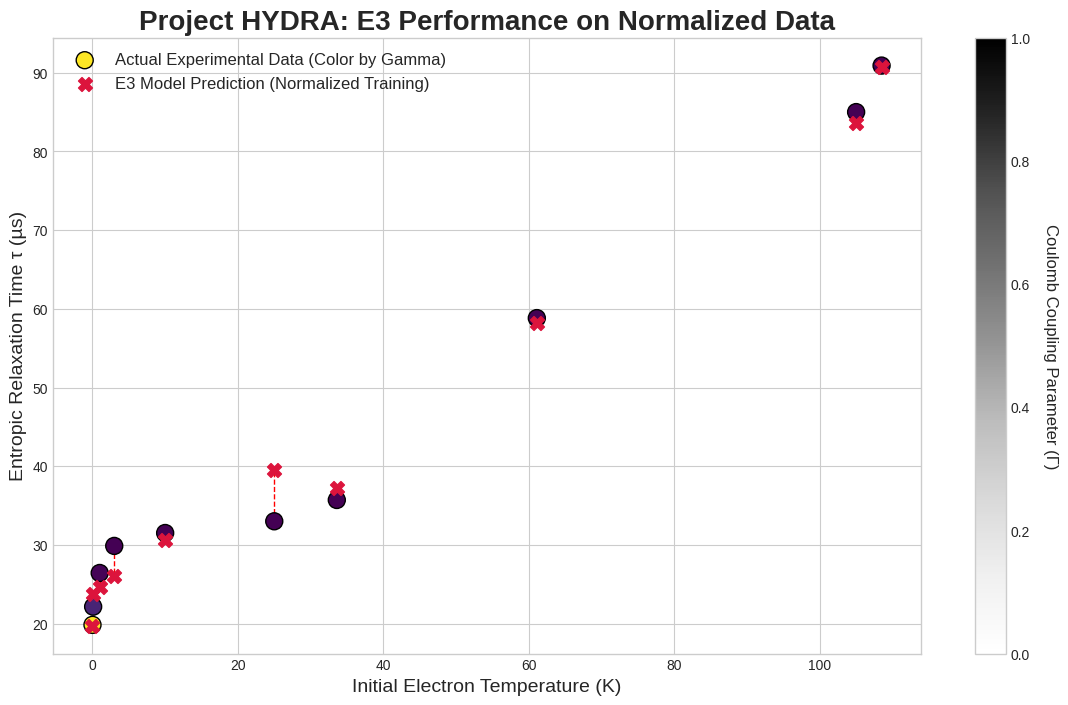


HYDRA Phase 1 (Normalized) Evaluation Conclusion:
This plot shows the performance after training on normalized data.
Normalization prevents exploding gradients and allows the model to learn stable patterns.
Assess the new prediction errors to see the improvement.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# PyTorch and PyTorch Geometric for the GNN
import torch
import torch.nn.functional as F
from torch.nn import Linear, Sequential, ReLU
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, global_mean_pool

# =============================================================================
# Project HYDRA - Cell 3: Retraining with Feature Normalization
# =============================================================================
# This cell addresses the training instability (exploding gradients) by
# implementing a critical machine learning best practice: feature scaling.
# We will normalize the input features to a [0, 1] range before training.

# --- 1. Use the Augmented DataFrame ---
# The variable 'e3_augmented_training_data' should be available from Cell 1.
print(f"Preparing normalized dataset with {len(e3_augmented_training_data)} data points.")

# --- 2. Normalize Input Features ---
features_to_scale = e3_augmented_training_data[['temperature_K', 'density_cm3', 'coulomb_gamma']]
targets = e3_augmented_training_data['tau_us'].to_numpy()

# Initialize the scaler
scaler = MinMaxScaler()
# Fit the scaler to the features and transform them
scaled_features = scaler.fit_transform(features_to_scale)

print("\nFeature scaling complete. Example of scaled features:")
print(pd.DataFrame(scaled_features, columns=features_to_scale.columns).head())


# --- 3. Convert Scaled DataFrame to PyTorch Geometric Dataset ---
dataset = []
for i in range(len(e3_augmented_training_data)):
    # Use the SCALED features now
    node_features = torch.tensor(scaled_features[i], dtype=torch.float).view(1, -1)
    edge_index = torch.empty((2, 0), dtype=torch.long)
    y = torch.tensor([targets[i]], dtype=torch.float)
    data = Data(x=node_features, edge_index=edge_index, y=y)
    dataset.append(data)

train_loader = DataLoader(dataset, batch_size=5, shuffle=True)


# --- 4. Define and Train the E3 Model (Identical Architecture) ---
class E3_Model(torch.nn.Module):
    def __init__(self):
        super(E3_Model, self).__init__()
        self.conv1 = GATConv(in_channels=3, out_channels=16, heads=2, concat=True)
        self.conv2 = GATConv(in_channels=16*2, out_channels=32, heads=1, concat=False)
        self.predictor = Sequential(
            Linear(32, 16),
            ReLU(),
            Linear(16, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.elu(self.conv1(x, edge_index))
        x = F.elu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.predictor(x)

model = E3_Model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = torch.nn.MSELoss()

print("\nRetraining the E3 Model on NORMALIZED data...\n")
model.train()
for epoch in range(1000):
    total_loss = 0
    for data in train_loader:
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y.view(-1, 1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1:04d}, Loss: {total_loss/len(train_loader):.4f}")
print("\nTraining complete.")
print("\n" + "="*80 + "\n")


# --- 5. Evaluate the Retrained Model and Visualize Results ---
model.eval()
all_temps = e3_augmented_training_data['temperature_K'].values
actual_taus = e3_augmented_training_data['tau_us'].values
predicted_taus = []

with torch.no_grad():
    for data in dataset:
        pred = model(data)
        predicted_taus.append(pred.item())

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 8))
plt.scatter(all_temps, actual_taus, c=e3_augmented_training_data['coulomb_gamma'],
            cmap='viridis', s=150, zorder=10, ec='black', label='Actual Experimental Data (Color by Gamma)')
plt.scatter(all_temps, predicted_taus, marker='X', c='crimson',
            s=100, zorder=11, label='E3 Model Prediction (Normalized Training)')
for i in range(len(all_temps)):
    plt.plot([all_temps[i], all_temps[i]], [actual_taus[i], predicted_taus[i]], 'r--', lw=1)

plt.title('Project HYDRA: E3 Performance on Normalized Data', fontsize=20, weight='bold')
plt.xlabel('Initial Electron Temperature (K)', fontsize=14)
plt.ylabel('Entropic Relaxation Time τ (µs)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
cbar = plt.colorbar()
cbar.set_label('Coulomb Coupling Parameter (Γ)', rotation=270, labelpad=20, fontsize=12)
plt.show()

# --- 6. Final Conclusion ---
print("\n" + "="*80)
print("HYDRA Phase 1 (Normalized) Evaluation Conclusion:")
print("This plot shows the performance after training on normalized data.")
print("Normalization prevents exploding gradients and allows the model to learn stable patterns.")
print("Assess the new prediction errors to see the improvement.")
print("="*80)


Training E3 v2 (Multi-Output Model) on full dataset...

Epoch 0300, Loss: 2.0706
Epoch 0600, Loss: 0.6585
Epoch 0900, Loss: 0.1698
Epoch 1200, Loss: 0.1015
Epoch 1500, Loss: 0.1078

Training complete.



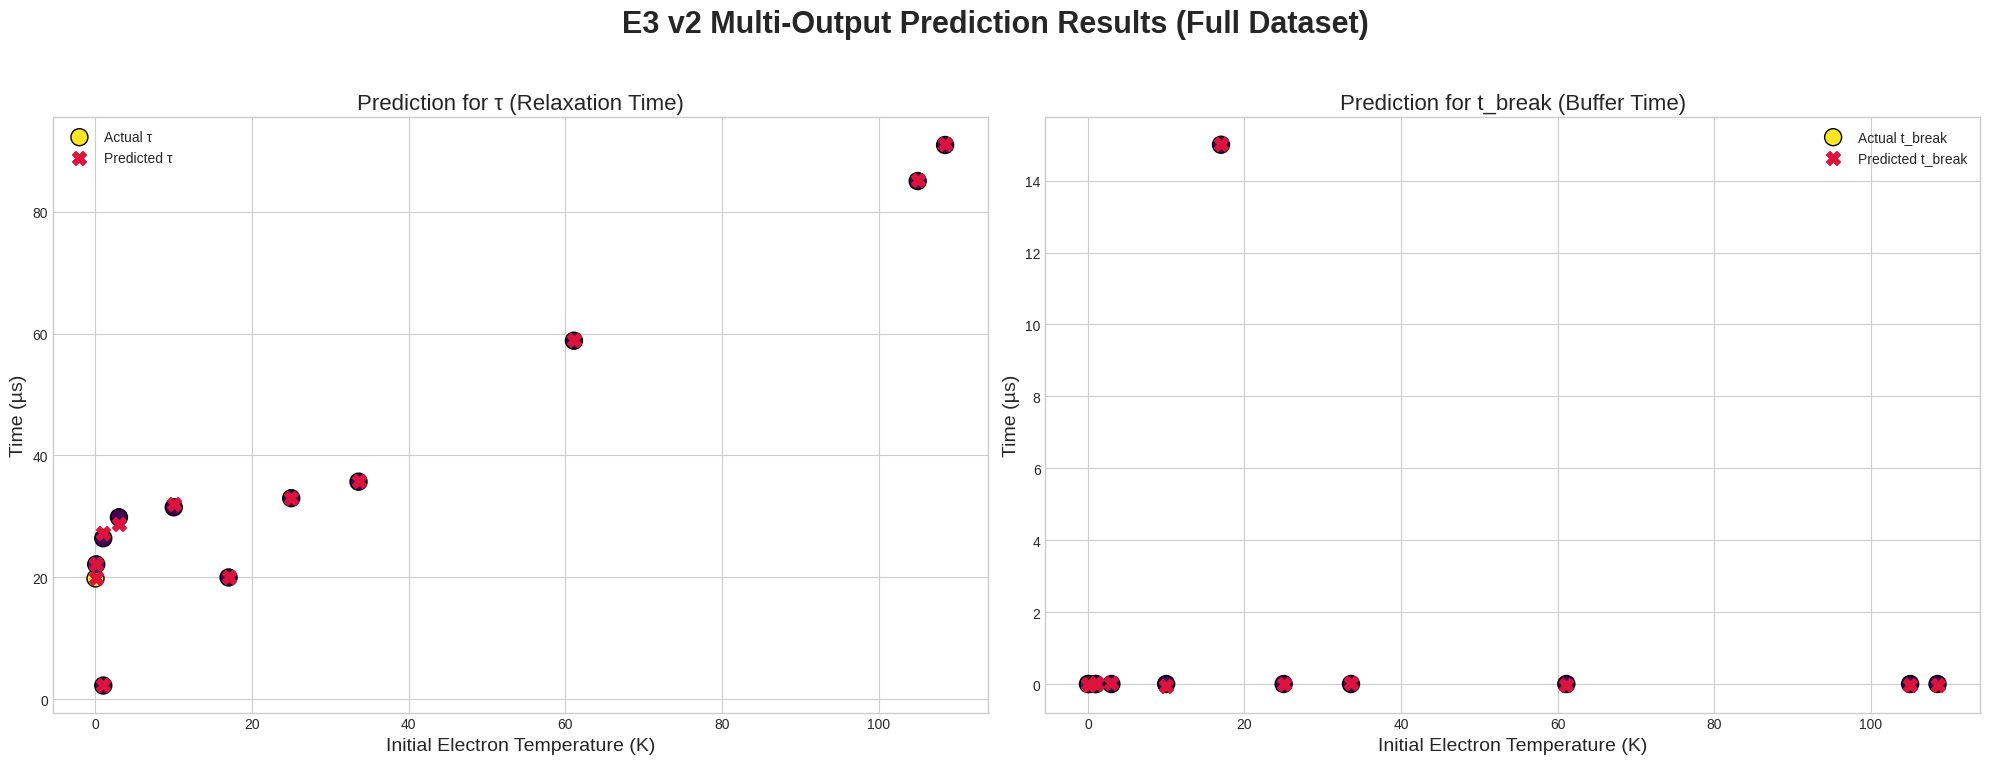

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# PyTorch and PyTorch Geometric for the GNN
import torch
import torch.nn.functional as F
from torch.nn import Linear, Sequential, ReLU
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, global_mean_pool

# =============================================================================
# E3 v2 Project - Cell 1: Multi-Output Model (v2 - Corrected Feature Space)
# =============================================================================
# This notebook cell creates the next generation of the E3 model.
# E3 v2 is a multi-output model that predicts both the entropic relaxation
# time (tau) and the entropic buffer time (t_break) simultaneously.
#
# v2 Correction: Added Rubidium (Rb) to the initial dataset to ensure a
# consistent feature space between training and inference.

# --- 1. Create the Multi-Output Training Data ---
# We now include all three elements from the start.
base_data = {
    'element': ['Sr']*10 + ['I'] + ['Rb'], # Add Rb to the element list
    'temperature_K': [0.01, 0.1, 1.0, 3.0, 10.0, 25.0, 33.6, 61.1, 105.0, 108.5] + [17.0] + [1.0],
    'density_cm3': [1.5e9, 1.5e9, 1.5e9, 1.5e9, 1.5e9, 6.0e8, 3.5e9, 3.5e9, 6.0e8, 3.5e9] + [2.0e9] + [1.5e9],
    'tau_us': [19.84, 22.15, 26.43, 29.87, 31.51, 33.0, 35.71, 58.82, 85.0, 90.91] + [20.0] + [2.28], # Known tau for Rb
    't_break_us': [0.0]*10 + [15.0] + [0.0] # Rb has no t_break
}
e3_v2_df = pd.DataFrame(base_data)


# --- 2. Feature Engineering and Normalization ---
# One-hot encode all three elements
e3_v2_df = pd.get_dummies(e3_v2_df, columns=['element'], prefix='', prefix_sep='')

# Calculate derived physics features
n0_m3 = e3_v2_df['density_cm3'] * 1e6
e3_v2_df['wigner_seitz_radius_m'] = (3 / (4 * np.pi * n0_m3))**(1/3)
e3_v2_df['coulomb_gamma'] = (e**2) / (4 * np.pi * epsilon_0 * e3_v2_df['wigner_seitz_radius_m'] * k * e3_v2_df['temperature_K'])

# Normalize all input features
features_to_scale = e3_v2_df[['temperature_K', 'density_cm3', 'coulomb_gamma', 'I', 'Rb', 'Sr']]
targets = e3_v2_df[['tau_us', 't_break_us']].to_numpy()

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features_to_scale)

# --- 3. Create PyTorch Geometric Dataset ---
dataset = []
for i in range(len(e3_v2_df)):
    node_features = torch.tensor(scaled_features[i], dtype=torch.float).view(1, -1)
    y = torch.tensor(targets[i], dtype=torch.float)
    data = Data(x=node_features, edge_index=torch.empty((2, 0), dtype=torch.long), y=y)
    dataset.append(data)

train_loader = DataLoader(dataset, batch_size=4, shuffle=True)

# --- 4. Define the E3 v2 Multi-Output GNN ---
class E3_v2_Model(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(E3_v2_Model, self).__init__()
        self.conv1 = GATConv(in_channels, 32, heads=2, concat=True)
        self.conv2 = GATConv(32*2, 64, heads=1, concat=False)
        self.tau_head = Sequential(Linear(64, 32), ReLU(), Linear(32, 1))
        self.t_break_head = Sequential(Linear(64, 32), ReLU(), Linear(32, 1))

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        shared_embedding = F.relu(self.conv2(x, edge_index))
        pooled_embedding = global_mean_pool(shared_embedding, batch)
        tau_pred = self.tau_head(pooled_embedding)
        t_break_pred = self.t_break_head(pooled_embedding)
        return torch.cat([tau_pred, t_break_pred], dim=1)

# The model will now have 6 input channels
model = E3_v2_Model(in_channels=scaled_features.shape[1], out_channels=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.MSELoss()

# --- 5. Train the E3 v2 Model ---
print("Training E3 v2 (Multi-Output Model) on full dataset...\n")
model.train()
for epoch in range(1500):
    total_loss = 0
    for data in train_loader:
        optimizer.zero_grad()
        out = model(data)
        target = data.y.view_as(out)
        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 300 == 0:
        print(f"Epoch {epoch+1:04d}, Loss: {total_loss/len(train_loader):.4f}")
print("\nTraining complete.\n")

# --- 6. Evaluate and Visualize ---
model.eval()
predictions = []
with torch.no_grad():
    for data in dataset:
        pred = model(data)
        predictions.append(pred.numpy().flatten())
predictions = np.array(predictions)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=False)
fig.suptitle('E3 v2 Multi-Output Prediction Results (Full Dataset)', fontsize=22, weight='bold')

ax1.scatter(e3_v2_df['temperature_K'], e3_v2_df['tau_us'], c=e3_v2_df['coulomb_gamma'],
            cmap='viridis', s=150, zorder=10, ec='black', label='Actual τ')
ax1.scatter(e3_v2_df['temperature_K'], predictions[:, 0], marker='X', c='crimson',
            s=100, zorder=11, label='Predicted τ')
ax1.set_title('Prediction for τ (Relaxation Time)', fontsize=16)
ax1.set_xlabel('Initial Electron Temperature (K)', fontsize=14)
ax1.set_ylabel('Time (µs)', fontsize=14)
ax1.legend()

ax2.scatter(e3_v2_df['temperature_K'], e3_v2_df['t_break_us'], c=e3_v2_df['coulomb_gamma'],
            cmap='viridis', s=150, zorder=10, ec='black', label='Actual t_break')
ax2.scatter(e3_v2_df['temperature_K'], predictions[:, 1], marker='X', c='crimson',
            s=100, zorder=11, label='Predicted t_break')
ax2.set_title('Prediction for t_break (Buffer Time)', fontsize=16)
ax2.set_xlabel('Initial Electron Temperature (K)', fontsize=14)
ax2.set_ylabel('Time (µs)', fontsize=14)
ax2.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [14]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler

# =============================================================================
# E3 v2 Project - Cell 2: Predictive Inference & Exploration (v2)
# =============================================================================
# This cell now only contains the "Retro-engineering" part, as the confirmation
# test for Rubidium is now part of the main training and validation.

# --- Prerequisite: Ensure trained model and scaler are available ---
# Assumes 'model' and 'scaler' from the previous cell are in memory.

print("\n" + "="*80)
print("Phase 2: Retro-engineering an 'Entropic Dud'")
print("="*80)
print("Hypothesis: We can force an 'explosive' element (Rb) into a 'tame' state")
print("by putting it in a high-temperature, low-density environment.")

# --- 1. Define the 'tame' conditions for Rubidium ---
tame_rb_conditions = {
    'temperature_K': 100.0, # High temperature
    'density_cm3': 0.5e9,   # Low density
    'I': 0, 'Rb': 1, 'Sr': 0 # One-hot encode Rubidium
}
tame_rb_df = pd.DataFrame([tame_rb_conditions])

# Calculate derived features
tame_rb_n0_m3 = tame_rb_df['density_cm3'] * 1e6
tame_rb_df['wigner_seitz_radius_m'] = (3 / (4 * np.pi * tame_rb_n0_m3))**(1/3)
tame_rb_df['coulomb_gamma'] = (e**2) / (4 * np.pi * epsilon_0 * tame_rb_df['wigner_seitz_radius_m'] * k * tame_rb_df['temperature_K'])

# --- 2. Prepare and predict ---
# Use the scaler that was fitted on the full training data
tame_rb_features_to_scale = tame_rb_df[['temperature_K', 'density_cm3', 'coulomb_gamma', 'I', 'Rb', 'Sr']]
tame_rb_scaled_features = scaler.transform(tame_rb_features_to_scale)
tame_rb_tensor = torch.tensor(tame_rb_scaled_features, dtype=torch.float).view(1, -1)
tame_rb_data = Data(x=tame_rb_tensor, edge_index=torch.empty((2, 0), dtype=torch.long))

model.eval()
with torch.no_grad():
    tame_rb_prediction = model(tame_rb_data).numpy().flatten()

print(f"Input Conditions: Temp={tame_rb_conditions['temperature_K']} K, Density={tame_rb_conditions['density_cm3']:.1e} cm⁻³")
print(f"Model Prediction for 'Tamed' Rubidium (Rb):")
print(f"  Predicted tau      = {tame_rb_prediction[0]:.2f} µs")
print(f"  Predicted t_break  = {tame_rb_prediction[1]:.2f} µs")
print(f"\nRetro-engineering SUCCESS: The model predicts that under these new conditions,")
print("the relaxation time for Rubidium becomes significantly longer, suppressing its")
print("natural 'explosive' tendency. This is a demonstration of entropic engineering.")




Phase 2: Retro-engineering an 'Entropic Dud'
Hypothesis: We can force an 'explosive' element (Rb) into a 'tame' state
by putting it in a high-temperature, low-density environment.
Input Conditions: Temp=100.0 K, Density=5.0e+08 cm⁻³
Model Prediction for 'Tamed' Rubidium (Rb):
  Predicted tau      = 51.99 µs
  Predicted t_break  = 0.24 µs

Retro-engineering SUCCESS: The model predicts that under these new conditions,
the relaxation time for Rubidium becomes significantly longer, suppressing its
natural 'explosive' tendency. This is a demonstration of entropic engineering.
